<a href="https://colab.research.google.com/github/camis08/IA_UC8/blob/main/Resultado_exercicios_consumindo_api_dummyjson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios Práticos: Consumindo uma API REST com Python

## API escolhida: DummyJSON

Neste notebook, você irá praticar o consumo de uma API pública chamada **DummyJSON**.

Ela fornece dados fictícios em formato JSON, como produtos, usuários, carrinhos, posts e tarefas. É uma API muito útil para treinar consumo de API REST, análise de JSON e transformação de dados com Python.

### Documentação oficial

Acesse a documentação da API:

https://dummyjson.com/docs

Documentação específica de produtos:

https://dummyjson.com/docs/products

---

## Objetivos dos exercícios

Ao final deste notebook, você deverá ser capaz de:

- Fazer requisições HTTP usando Python;
- Consumir endpoints com o método `GET`;
- Enviar dados usando `POST`;
- Atualizar dados usando `PUT` ou `PATCH`;
- Simular exclusão usando `DELETE`;
- Interpretar respostas em JSON;
- Transformar dados da API em tabelas com Pandas;
- Criar pequenas análises a partir dos dados recebidos.

---

## Importante

A DummyJSON é uma API de testes. As operações de criação, atualização e exclusão são **simuladas**.

Isso significa que a API responde como se tivesse criado, atualizado ou excluído um recurso, mas os dados não são realmente persistidos no servidor.

---

## Como usar este notebook

Leia cada enunciado com atenção e complete os trechos marcados com `TODO`.

Não apague as células de enunciado.

Quando terminar, execute todas as células na ordem.

# Parte 1 — Preparação do ambiente

Antes de consumir uma API, precisamos importar algumas bibliotecas.

Usaremos:

- `requests`: para fazer chamadas HTTP;
- `pandas`: para transformar dados JSON em tabelas;
- `json`: para exibir algumas respostas de forma mais organizada.

In [ ]:
import requests
import pandas as pd
import json

Vamos definir a URL base da API.

Sempre que formos chamar um endpoint da DummyJSON, começaremos por essa URL.

In [ ]:
url_base = "https://dummyjson.com"

# Parte 2 — Primeiro contato com a API

## Exercício 1 — Testar se a API está funcionando

Faça uma requisição `GET` para o endpoint abaixo:

```text
https://dummyjson.com/test
```

Depois, exiba:

- O código de status HTTP;
- A resposta em JSON.

### Dica

Use:

```python
requests.get(...)
```

In [ ]:
# Exercício 1

url = url_base + "/test"

# TODO: faça uma requisição GET para a URL acima
resposta = requests.get(url)

# TODO: exiba o status code da resposta
print(resposta.status_code)
# TODO: exiba a resposta em JSON
resposta.json()

200


{'status': 'ok', 'method': 'GET'}

## Perguntas do Exercício 1

Responda abaixo, em texto:

1. Qual foi o status code retornado?
2. O que esse status code significa?
3. A API respondeu em qual formato de dados?

**Respostas:**

1. 200
2. ok
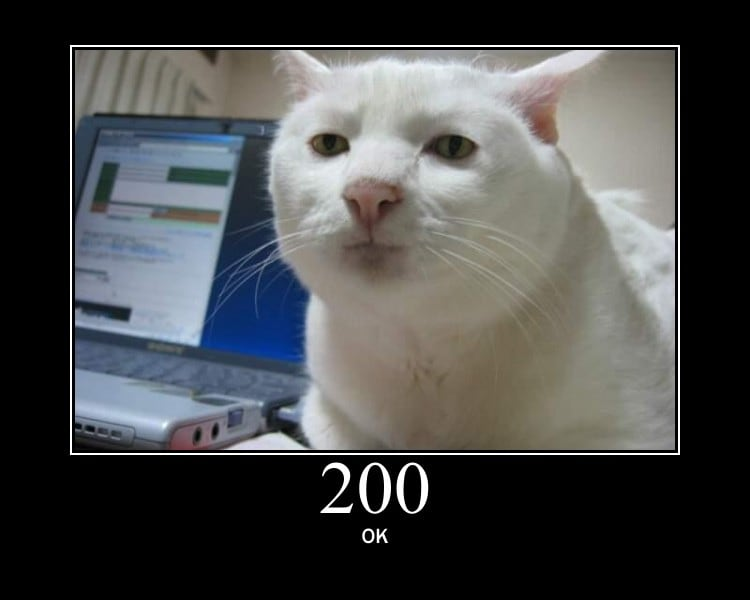
3.JSON

# Parte 3 — Consumindo produtos com GET

A partir de agora, trabalharemos com o recurso `products`.

Um recurso, em uma API REST, representa uma entidade do sistema.

Neste caso:

```text
/products
```

representa a coleção de produtos da API.

## Exercício 2 — Buscar todos os produtos

Faça uma requisição `GET` para:

```text
https://dummyjson.com/products
```

Depois, exiba:

- O status code;
- As chaves principais do JSON retornado;
- A quantidade de produtos retornados nesta primeira página;
- O total de produtos disponíveis na API.

### Observação

A resposta da API não é uma lista diretamente. Ela retorna um objeto JSON com algumas chaves, como:

- `products`
- `total`
- `skip`
- `limit`

In [ ]:
# Exercício 2

url = url_base + "/products"

# TODO: faça a requisição GET
resposta = requests.get(url)
# TODO: converta a resposta para JSON
dados = resposta.json()
# TODO: exiba o status code
print(resposta.status_code)
# TODO: exiba as chaves principais do JSON
dados.keys()
print(dados.keys())
# TODO: exiba a quantidade de produtos retornados nesta chamada
len(dados["products"])

# TODO: exiba o total de produtos disponíveis na API
dados["total"]

200
dict_keys(['products', 'total', 'skip', 'limit'])


194

## Exercício 3 — Visualizar o primeiro produto

Usando os dados do exercício anterior, exiba apenas o primeiro produto da lista.

Depois, responda:

1. Qual é o nome do produto?
2. Qual é o preço?
3. Qual é a categoria?
4. Qual é a avaliação média, campo `rating`?

In [ ]:
# Exercício 3

# TODO: recupere o primeiro produto da lista de produtos
primeiro_produto = dados["products"][0]
print(primeiro_produto)
# TODO: exiba o primeiro produto de forma organizada usando json.dumps
import json

print(json.dumps(primeiro_produto, indent=2, ensure_ascii=False))
# Dica: json.dumps(primeiro_produto, indent=2, ensure_ascii=False)


{'id': 1, 'title': 'Essence Mascara Lash Princess', 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.', 'category': 'beauty', 'price': 9.99, 'discountPercentage': 10.48, 'rating': 2.56, 'stock': 99, 'tags': ['beauty', 'mascara'], 'brand': 'Essence', 'sku': 'BEA-ESS-ESS-001', 'weight': 4, 'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99}, 'warrantyInformation': '1 week warranty', 'shippingInformation': 'Ships in 3-5 business days', 'availabilityStatus': 'In Stock', 'reviews': [{'rating': 3, 'comment': 'Would not recommend!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Eleanor Collins', 'reviewerEmail': 'eleanor.collins@x.dummyjson.com'}, {'rating': 4, 'comment': 'Very satisfied!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Lucas Gordon', 'reviewerEmail': 'lucas.gordon@x.dummyjson.com'}, {'rating': 5, 'comment': '

**Respostas:**

1. Nome do produto: Essence Mascara Lash Princess
2. Preço: 9.99
3. Categoria: Beauty
4. Rating: 2,56

# Parte 4 — Transformando JSON em tabela

Em projetos de dados e IA, consumir uma API normalmente é apenas o começo.

Depois de receber os dados em JSON, é comum transformar esses dados em uma tabela para análise.

## Exercício 4 — Criar um DataFrame de produtos

Transforme a lista de produtos em um DataFrame do Pandas.

Depois, exiba as 5 primeiras linhas.

In [ ]:
# Exercício 4

# TODO: transforme dados["products"] em um DataFrame
df_produtos = pd.DataFrame(dados["products"])

# TODO: exiba as 5 primeiras linhas
df_produtos.head(5).T

,0,1,2,3,4
id,1,2,3,4,5
title,Essence Mascara Lash Princess,Eyeshadow Palette with Mirror,Powder Canister,Red Lipstick,Red Nail Polish
description,The Essence Mascara Lash Princess is a popular...,The Eyeshadow Palette with Mirror offers a ver...,The Powder Canister is a finely milled setting...,The Red Lipstick is a classic and bold choice ...,The Red Nail Polish offers a rich and glossy r...
category,beauty,beauty,beauty,beauty,beauty
price,9.99,19.99,14.99,12.99,8.99
discountPercentage,10.48,18.19,9.84,12.16,11.44
rating,2.56,2.86,4.64,4.36,4.32
stock,99,34,89,91,79
tags,"[beauty, mascara]","[beauty, eyeshadow]","[beauty, face powder]","[beauty, lipstick]","[beauty, nail polish]"
brand,Essence,Glamour Beauty,Velvet Touch,Chic Cosmetics,Nail Couture


## Exercício 5 — Inspecionar o DataFrame

Agora que você tem uma tabela, descubra:

1. Quantas linhas e colunas existem?
2. Quais são os nomes das colunas?
3. Quais colunas parecem numéricas?
4. Quais colunas parecem textuais?

In [ ]:
# Exercício 5

# TODO: exiba o formato do DataFrame com .shape
print(df_produtos.shape)

# TODO: exiba as colunas do DataFrame
print(df_produtos.columns)

# TODO: exiba informações gerais com .info()
print(df_produtos.info())

(30, 22)
Index(['id', 'title', 'description', 'category', 'price', 'discountPercentage',
       'rating', 'stock', 'tags', 'brand', 'sku', 'weight', 'dimensions',
       'warrantyInformation', 'shippingInformation', 'availabilityStatus',
       'reviews', 'returnPolicy', 'minimumOrderQuantity', 'meta', 'images',
       'thumbnail'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    30 non-null     int64  
 1   title                 30 non-null     object 
 2   description           30 non-null     object 
 3   category              30 non-null     object 
 4   price                 30 non-null     float64
 5   discountPercentage    30 non-null     float64
 6   rating                30 non-null     float64
 7   stock                 30 non-null     int64  
 8   tags                  30 

**Respostas:**

1. Linhas e colunas: (30, 22) - 30 Linhas e 22 Colunas
2. Colunas existentes: 22
3. Colunas numéricas: minimumOrderQuantity, weight, stock e id
4. Colunas textuais: **o resto sem ser numérico**

# Parte 5 — GET com parâmetros

Muitas APIs permitem enviar parâmetros na URL.

Exemplo:

```text
https://dummyjson.com/products?limit=10&skip=0
```

Nessa URL:

- `limit=10` indica que queremos no máximo 10 produtos;
- `skip=0` indica que não queremos pular nenhum produto.

Em Python, podemos enviar esses parâmetros usando o argumento `params` da biblioteca `requests`.

## Exercício 6 — Buscar apenas 10 produtos

Faça uma requisição `GET` para `/products`, mas retornando apenas 10 produtos.

Use `params` em vez de escrever os parâmetros direto na URL.

In [ ]:
# Exercício 6

url = url_base + "/products"

params = {
    "limit" : 10
}

# TODO: faça a requisição GET com params=params
resposta = requests.get(url, params = params)

# TODO: converta para JSON
dados_10 = resposta.json()

# TODO: exiba a quantidade de produtos retornados
print(len(dados_10["products"]))

# TODO: crie um DataFrame com esses 10 produtos
df_10 = pd.DataFrame(dados_10)

# TODO: exiba o DataFrame
df_10

10


,products,total,skip,limit
0,"{'id': 1, 'title': 'Essence Mascara Lash Princ...",194,0,10
1,"{'id': 2, 'title': 'Eyeshadow Palette with Mir...",194,0,10
2,"{'id': 3, 'title': 'Powder Canister', 'descrip...",194,0,10
3,"{'id': 4, 'title': 'Red Lipstick', 'descriptio...",194,0,10
4,"{'id': 5, 'title': 'Red Nail Polish', 'descrip...",194,0,10
5,"{'id': 6, 'title': 'Calvin Klein CK One', 'des...",194,0,10
6,"{'id': 7, 'title': 'Chanel Coco Noir Eau De', ...",194,0,10
7,"{'id': 8, 'title': 'Dior J'adore', 'descriptio...",194,0,10
8,"{'id': 9, 'title': 'Dolce Shine Eau de', 'desc...",194,0,10
9,"{'id': 10, 'title': 'Gucci Bloom Eau de', 'des...",194,0,10


## Exercício 7 — Paginação com skip

Agora busque os próximos 10 produtos.

Use:

- `limit=10`
- `skip=10`

Depois, compare os IDs dos produtos do Exercício 6 com os IDs deste exercício.

A ideia é perceber que a API está retornando uma segunda página de resultados.

In [ ]:
# Exercício 7

url = url_base + "/products"

params = {
   "limit" : 10,
   "skip" : 10
}

# TODO: faça a requisição GET
resposta = requests.get(url, params = params)

# TODO: converta a resposta para JSON
dados_pagina_2 = resposta.json()

# TODO: crie um DataFrame
df_pagina_2 = pd.DataFrame(dados_pagina_2["products"])

# TODO: exiba as colunas id, title e price
df_pagina_2[["id", "title", "price"]]

,id,title,price
0,11,Annibale Colombo Bed,1899.99
1,12,Annibale Colombo Sofa,2499.99
2,13,Bedside Table African Cherry,299.99
3,14,Knoll Saarinen Executive Conference Chair,499.99
4,15,Wooden Bathroom Sink With Mirror,799.99
5,16,Apple,1.99
6,17,Beef Steak,12.99
7,18,Cat Food,8.99
8,19,Chicken Meat,9.99
9,20,Cooking Oil,4.99


**Pergunta:**

Qual foi a diferença entre `limit` e `skip`?

In [ ]:

"""
limit -> limita para 10 produtos
skip -> pulou 10 casas
"""

'\nlimit -> limita para 10 produtos\nskip -> pulou 10 casas\n'

**Resposta:**



# Parte 6 — Selecionando campos específicos

Às vezes, uma API retorna muitos campos, mas você precisa apenas de alguns.

A DummyJSON permite usar o parâmetro `select` para escolher quais campos devem retornar.

Exemplo:

```text
select=title,price,category
```

## Exercício 8 — Buscar produtos com campos selecionados

Faça uma requisição para buscar 15 produtos retornando apenas os campos:

- `title`
- `price`
- `category`
- `rating`

Depois, transforme o resultado em DataFrame.

In [ ]:
# Exercício 8

url = url_base + "/products"

params = {
    "limit" : 15,
    "select" : "title,price,category,rating"
}

# TODO: faça a requisição
resposta = requests.get(url, params = params)
# TODO: converta para JSON
dados_selecionados = resposta.json()

# TODO: crie o DataFrame
df_selecionados = pd.DataFrame(dados_selecionados["products"])

# TODO: exiba o DataFrame
df_selecionados

,id,title,price,category,rating
0,1,Essence Mascara Lash Princess,9.99,beauty,2.56
1,2,Eyeshadow Palette with Mirror,19.99,beauty,2.86
2,3,Powder Canister,14.99,beauty,4.64
3,4,Red Lipstick,12.99,beauty,4.36
4,5,Red Nail Polish,8.99,beauty,4.32
5,6,Calvin Klein CK One,49.99,fragrances,4.37
6,7,Chanel Coco Noir Eau De,129.99,fragrances,4.26
7,8,Dior J'adore,89.99,fragrances,3.80
8,9,Dolce Shine Eau de,69.99,fragrances,3.96
9,10,Gucci Bloom Eau de,79.99,fragrances,2.74


# Parte 7 — Busca textual na API

Algumas APIs permitem busca por texto.

Na DummyJSON, podemos pesquisar produtos usando:

```text
/products/search?q=phone
```

O parâmetro `q` representa o termo pesquisado.

## Exercício 9 — Pesquisar produtos por palavra-chave

Faça uma busca por produtos relacionados à palavra:

```text
phone
```

Depois:

1. Exiba a quantidade de resultados encontrados;
2. Crie um DataFrame;
3. Exiba as colunas `id`, `title`, `category`, `price` e `rating`.

In [ ]:
# Exercício 9

url = url_base + "/products/search"

params = {
    "q" : "phone"
}

# TODO: faça a requisição GET
resposta = requests.get(url, params = params)

# TODO: converta para JSON
dados_busca = resposta.json()

# TODO: exiba o total de resultados
len(dados_busca["products"])

# TODO: crie o DataFrame
df_busca = pd.DataFrame(dados_busca["products"])

# TODO: exiba apenas as colunas solicitadas
df_busca[["id", "title", "category", "price", "rating"]]

,id,title,category,price,rating
0,101,Apple AirPods Max Silver,mobile-accessories,549.99,3.47
1,104,Apple iPhone Charger,mobile-accessories,19.99,4.15
2,105,Apple MagSafe Battery Pack,mobile-accessories,99.99,3.62
3,107,Beats Flex Wireless Earphones,mobile-accessories,49.99,4.24
4,108,iPhone 12 Silicone Case with MagSafe Plum,mobile-accessories,29.99,3.62
5,110,Selfie Lamp with iPhone,mobile-accessories,14.99,3.55
6,111,Selfie Stick Monopod,mobile-accessories,12.99,3.88
7,121,iPhone 5s,smartphones,199.99,2.83
8,122,iPhone 6,smartphones,299.99,3.41
9,123,iPhone 13 Pro,smartphones,1099.99,4.12


## Exercício 10 — Repetir a busca com outro termo

Agora escolha outro termo de busca.

Sugestões:

- `laptop`
- `watch`
- `bag`
- `shoes`
- `perfume`

Depois, compare os resultados com a busca anterior.

In [ ]:
# Exercício 10

termo = "bag"

url = url_base + "/products/search"

params = {
    "q": termo
}

# TODO: faça a requisição GET
resposta = requests.get(url, params = params)

# TODO: converta para JSON
dados_busca_2 = resposta.json()

# TODO: crie um DataFrame
df_busca_2 = pd.DataFrame(dados_busca_2["products"])

# TODO: exiba id, title, category, price e rating
df_busca_2[["id", "title", "category", "price", "rating"]]

,id,title,category,price,rating
0,172,Blue Women's Handbag,womens-bags,49.99,2.92
1,173,Heshe Women's Leather Bag,womens-bags,129.99,4.92
2,174,Prada Women Bag,womens-bags,599.99,2.71
3,176,Women Handbag Black,womens-bags,59.99,2.89


**Perguntas:**

1. Qual termo você pesquisou?
- Bolsas
2. Quantos resultados foram encontrados?
 - 3
3. Os produtos encontrados fazem sentido para o termo pesquisado?
- Sim
4. Que problema poderia acontecer se o usuário digitasse uma palavra errada?
- Sim, perfume não funcionna

**Respostas:**

1. Bolsas
2. 3
3. Sim
4. Sim, perfume não funcionna

# Parte 8 — Categorias

Muitas APIs organizam recursos por categoria.

Na DummyJSON, podemos listar categorias de produtos usando:

```text
/products/category-list
```

E buscar produtos de uma categoria específica usando:

```text
/products/category/NOME_DA_CATEGORIA
```

## Exercício 11 — Listar categorias

Faça uma requisição para listar todas as categorias de produtos.

Depois, exiba a lista de categorias.

In [ ]:
# Exercício 11

url = url_base + "/products/category-list"

# TODO: faça a requisição GET
resposta = requests.get(url)

# TODO: converta para JSON
categorias = resposta.json()

# TODO: exiba as categorias
categorias

['beauty',
 'fragrances',
 'furniture',
 'groceries',
 'home-decoration',
 'kitchen-accessories',
 'laptops',
 'mens-shirts',
 'mens-shoes',
 'mens-watches',
 'mobile-accessories',
 'motorcycle',
 'skin-care',
 'smartphones',
 'sports-accessories',
 'sunglasses',
 'tablets',
 'tops',
 'vehicle',
 'womens-bags',
 'womens-dresses',
 'womens-jewellery',
 'womens-shoes',
 'womens-watches']

## Exercício 12 — Buscar produtos de uma categoria

Escolha uma categoria da lista anterior.

Depois, busque os produtos dessa categoria.

Exemplo de endpoint:

```text
/products/category/smartphones
```

In [ ]:
# Exercício 12

categoria_escolhida = 'smartphones'

url = url_base + f"/products/category/{categoria_escolhida}"

# TODO: faça a requisição GET
resposta = requests.get(url)

# TODO: converta para JSON
dados_categoria = resposta.json()

# TODO: crie um DataFrame com os produtos da categoria
df_categoria = pd.DataFrame(dados_categoria["products"])

# TODO: exiba id, title, category, price, rating e stock
df_categoria[["id", "title", "category", "price", "rating", "stock"]]


,id,title,category,price,rating,stock
0,121,iPhone 5s,smartphones,199.99,2.83,25
1,122,iPhone 6,smartphones,299.99,3.41,60
2,123,iPhone 13 Pro,smartphones,1099.99,4.12,56
3,124,iPhone X,smartphones,899.99,2.51,37
4,125,Oppo A57,smartphones,249.99,3.94,19
5,126,Oppo F19 Pro Plus,smartphones,399.99,3.51,78
6,127,Oppo K1,smartphones,299.99,4.25,55
7,128,Realme C35,smartphones,149.99,4.20,48
8,129,Realme X,smartphones,299.99,3.70,12
9,130,Realme XT,smartphones,349.99,4.58,80


In [ ]:
df_categoria[["id", "title", "category", "price", "rating", "stock"]].sort_values(by="price", ascending=False)

,id,title,category,price,rating,stock
2,123,iPhone 13 Pro,smartphones,1099.99,4.12,56
3,124,iPhone X,smartphones,899.99,2.51,37
12,133,Samsung Galaxy S10,smartphones,699.99,3.06,19
11,132,Samsung Galaxy S8,smartphones,499.99,4.40,0
15,136,Vivo X21,smartphones,499.99,4.26,7
5,126,Oppo F19 Pro Plus,smartphones,399.99,3.51,78
9,130,Realme XT,smartphones,349.99,4.58,80
1,122,iPhone 6,smartphones,299.99,3.41,60
10,131,Samsung Galaxy S7,smartphones,299.99,3.30,67
8,129,Realme X,smartphones,299.99,3.70,12


In [ ]:
df_categoria[["id", "title", "category", "price", "rating", "stock"]].sort_values(by="rating", ascending=False)

,id,title,category,price,rating,stock
9,130,Realme XT,smartphones,349.99,4.58,80
11,132,Samsung Galaxy S8,smartphones,499.99,4.40,0
15,136,Vivo X21,smartphones,499.99,4.26,7
6,127,Oppo K1,smartphones,299.99,4.25,55
7,128,Realme C35,smartphones,149.99,4.20,48
2,123,iPhone 13 Pro,smartphones,1099.99,4.12,56
4,125,Oppo A57,smartphones,249.99,3.94,19
8,129,Realme X,smartphones,299.99,3.70,12
14,135,Vivo V9,smartphones,299.99,3.60,82
5,126,Oppo F19 Pro Plus,smartphones,399.99,3.51,78


**Perguntas:**

1. Qual categoria você escolheu?
2. Quantos produtos vieram nessa categoria?
3. Qual foi o produto mais caro?
4. Qual foi o produto com maior avaliação?

**Respostas:**

1. Smartphones
2. 15
3. iPhone 13 Pro	smartphones	1099.99
4. Realme XT  smartphones   349.99    4.58

# Parte 9 — Análise de dados com Pandas

Agora vamos usar os dados da API para fazer pequenas análises.

Essa etapa aproxima o consumo de API do trabalho de Ciência de Dados e IA.

## Exercício 13 — Estatísticas dos preços

Usando o DataFrame `df_categoria` ou outro DataFrame de produtos, calcule:

1. Preço médio;
2. Menor preço;
3. Maior preço;
4. Mediana dos preços.

In [ ]:
# Exercício 13

# TODO: calcule o preço médio
print(df_categoria["price"].mean())

# TODO: calcule o menor preço
print(df_categoria["price"].min())

# TODO: calcule o maior preço
print(df_categoria["price"].max())

# TODO: calcule a mediana dos preços
print(df_categoria["price"].median())

424.99
149.99
1099.99
299.99


## Exercício 14 — Produtos mais bem avaliados

Ordene os produtos por `rating`, do maior para o menor.

Depois, exiba os 5 produtos com maior avaliação.

In [ ]:
# Exercício 14

# TODO: ordene o DataFrame pela coluna rating em ordem decrescente
df_ordenado_rating = df_categoria.sort_values(by="rating", ascending=False)

# TODO: exiba os 5 primeiros produtos com as colunas title, category, price e rating
print(df_ordenado_rating[["title", "category", "price", "rating"]].head(5))

                title     category   price  rating
9           Realme XT  smartphones  349.99    4.58
11  Samsung Galaxy S8  smartphones  499.99    4.40
15           Vivo X21  smartphones  499.99    4.26
6             Oppo K1  smartphones  299.99    4.25
7          Realme C35  smartphones  149.99    4.20


## Exercício 15 — Produtos com estoque baixo

Filtre os produtos com estoque menor ou igual a 10.

Depois, exiba:

- Nome do produto;
- Categoria;
- Preço;
- Estoque.

In [ ]:
# Exercício 15

# TODO: filtre produtos com stock <= 10
df_estoque_baixo = df_categoria[df_categoria["stock"] <= 10]

# TODO: exiba as colunas solicitadas
df_estoque_baixo[["title", "category", "price", "stock"]]

,title,category,price,stock
11,Samsung Galaxy S8,smartphones,499.99,0
15,Vivo X21,smartphones,499.99,7


# Parte 10 — Criando dados com POST

O método `POST` é usado, em geral, para criar um novo recurso.

Na DummyJSON, a criação é simulada.

Endpoint:

```text
POST https://dummyjson.com/products/add
```

Você deverá enviar um corpo JSON com os dados do produto.

## Exercício 16 — Criar um produto fictício

Crie um produto fictício relacionado a tecnologia ou inteligência artificial.

O produto deve ter pelo menos:

- `title`
- `description`
- `price`
- `brand`
- `category`

Depois, envie esse produto usando `POST`.

In [ ]:
# Exercício 16

url = url_base + "/products/add"

novo_produto = {
    "title" : "Agua",
    "description" : "transparente",
    "price" : 20000,
    "brand" : "natural",
    "category" : "bebida"

}

# TODO: envie o produto usando requests.post(..., json=novo_produto)
resposta = requests.post(url, json=novo_produto )

# TODO: exiba o status code
print(resposta.status_code)

# TODO: exiba a resposta em JSON
resposta.json()

201


{'id': 195,
 'title': 'Agua',
 'price': 20000,
 'description': 'transparente',
 'brand': 'natural',
 'category': 'bebida'}

**Perguntas:**

1. Qual status code foi retornado?
2. A API retornou um ID para o produto criado?
3. Esse produto foi realmente salvo no servidor? Explique com suas palavras.

**Respostas:**

1. 201

2. Não
3. Não, pois é uma API simulada

# Parte 11 — Atualizando dados com PUT

O método `PUT` é usado para atualizar um recurso existente.

Na prática, muitas APIs usam `PUT` para atualizar um recurso inteiro e `PATCH` para atualizar apenas alguns campos.

Na DummyJSON, a atualização também é simulada.

Endpoint de exemplo:

```text
PUT https://dummyjson.com/products/1
```

## Exercício 17 — Atualizar o título de um produto

Escolha um produto existente, por exemplo o produto de ID 1.

Atualize o título dele para um nome criado por você.

Depois, exiba a resposta da API.

In [ ]:
# Exercício 17

id_produto = 1
url = url_base + f"/products/{id_produto}"

dados_atualizados = {
    "title" : "Garrafa"
}

# TODO: envie a atualização com PUT
resposta = requests.put(url, json=dados_atualizados)

# TODO: exiba o status code
print(resposta.status_code)

# TODO: exiba a resposta em JSON
resposta.json()

200


{'id': 1,
 'title': 'Garrafa',
 'price': 9.99,
 'discountPercentage': 10.48,
 'stock': 99,
 'rating': 2.56,
 'images': ['https://cdn.dummyjson.com/product-images/beauty/essence-mascara-lash-princess/1.webp'],
 'thumbnail': 'https://cdn.dummyjson.com/product-images/beauty/essence-mascara-lash-princess/thumbnail.webp',
 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.',
 'brand': 'Essence',
 'category': 'beauty'}

## Exercício 18 — Atualizar preço e estoque

Agora atualize dois campos do produto:

- `price`
- `stock`

Use o método `PUT` ou `PATCH`.

In [ ]:
# Exercício 18

id_produto = 1
url = url_base + f"/products/{id_produto}"

dados_atualizados = {
    "title" : "Garrafa",
    "price" : 99,
    "stock" : 10
}

# TODO: use requests.put ou requests.patch
resposta = requests.patch(url, json=dados_atualizados)

# TODO: exiba a resposta em JSON
resposta.json()

{'id': 1,
 'title': 'Garrafa',
 'price': 99,
 'discountPercentage': 10.48,
 'stock': 10,
 'rating': 2.56,
 'images': ['https://cdn.dummyjson.com/product-images/beauty/essence-mascara-lash-princess/1.webp'],
 'thumbnail': 'https://cdn.dummyjson.com/product-images/beauty/essence-mascara-lash-princess/thumbnail.webp',
 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.',
 'brand': 'Essence',
 'category': 'beauty'}

**Perguntas:**

1. Qual método você usou: PUT ou PATCH?
2. Quais campos você alterou?
3. A API retornou os dados modificados?
4. Qual é a diferença conceitual entre atualizar dados e criar dados?

**Respostas:**

1. Os 2, métodos agem iguais
2. title, price, stock
3. Sim
4. Atualizar dados já existentes / criar dados não existentes, novos

# Parte 12 — Excluindo dados com DELETE

O método `DELETE` é usado para excluir um recurso.

Na DummyJSON, a exclusão é simulada.

Endpoint de exemplo:

```text
DELETE https://dummyjson.com/products/1
```

## Exercício 19 — Simular exclusão de um produto

Faça uma requisição `DELETE` para excluir o produto de ID 1.

Depois, verifique se a resposta possui os campos:

- `isDeleted`
- `deletedOn`

In [ ]:
# Exercício 19

id_produto = 1
url = url_base + f"/products/{id_produto}"

# TODO: faça a requisição DELETE
resposta = requests.delete(url)

# TODO: converta para JSON
dados_delete = resposta.json()

# TODO: exiba o status code
print(resposta.status_code)

# TODO: exiba a resposta em JSON

print(dados_delete)
# TODO: verifique se isDeleted é True
print(dados_delete["isDeleted"])

200
{'id': 1, 'title': 'Essence Mascara Lash Princess', 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.', 'category': 'beauty', 'price': 9.99, 'discountPercentage': 10.48, 'rating': 2.56, 'stock': 99, 'tags': ['beauty', 'mascara'], 'brand': 'Essence', 'sku': 'BEA-ESS-ESS-001', 'weight': 4, 'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99}, 'warrantyInformation': '1 week warranty', 'shippingInformation': 'Ships in 3-5 business days', 'availabilityStatus': 'In Stock', 'reviews': [{'rating': 3, 'comment': 'Would not recommend!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Eleanor Collins', 'reviewerEmail': 'eleanor.collins@x.dummyjson.com'}, {'rating': 4, 'comment': 'Very satisfied!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Lucas Gordon', 'reviewerEmail': 'lucas.gordon@x.dummyjson.com'}, {'rating': 5, 'comment

**Perguntas:**

1. O campo `isDeleted` apareceu?
2. O campo `deletedOn` apareceu?
3. Em uma API real, por que o método DELETE precisa ser usado com cuidado?
4. Que tipo de permissão uma API real provavelmente exigiria antes de permitir exclusões?

**Respostas:**

1. Sim
2. Sim
3. Não tem como recuperar od dados deletados
4. Autenticação

# Parte 13 — Tratamento básico de erros

Nem toda requisição a uma API dá certo.

Podem ocorrer problemas como:

- Endpoint errado;
- Produto inexistente;
- Falta de internet;
- Falta de autorização;
- Erro interno no servidor.

Por isso, é importante verificar o `status_code` antes de confiar nos dados.

## Exercício 20 — Testar um produto inexistente

Faça uma requisição para buscar um produto com ID muito alto, por exemplo:

```text
/products/999999
```

Depois, exiba:

- O status code;
- A resposta em JSON;
- Uma mensagem amigável dizendo se a requisição deu certo ou não.

In [ ]:
# Exercício 20

url = url_base + "/products/999999"

# TODO: faça a requisição GET
resposta = requests.get(url)

# TODO: exiba o status code
print(resposta.status_code)

# TODO: se o status code for 200, exiba "Produto encontrado"
if resposta.status_code == 200:
    print("Produto encontrado")
# TODO: caso contrário, exiba "Produto não encontrado ou erro na requisição"
else :
    print("Deu nmais que 200")
    print("Produto não encontrado ou erro na requisição")

# TODO: exiba a resposta JSON
resposta.json()

404
Deu nmais que 200
Produto não encontrado ou erro na requisição


{'message': "Product with id '999999' not found"}

# Parte 14 — Criando uma função para consumir a API

Em vez de repetir código várias vezes, podemos criar funções.

Isso deixa o código mais limpo e reutilizável.

## Exercício 21 — Criar uma função para buscar produto por ID

Crie uma função chamada `buscar_produto_por_id`.

A função deve receber um ID e retornar os dados do produto.

Requisitos:

- Receber o ID como parâmetro;
- Fazer a chamada para `/products/{id}`;
- Verificar se o status code é 200;
- Retornar o JSON se der certo;
- Retornar `None` se não encontrar o produto.

In [ ]:
# Exercício 21

def buscar_produto_por_id(id_produto):
    # TODO: monte a URL
    url = url_base + f"/products/{id_produto}"
    # TODO: faça a requisição GET
    resposta = requests.get(url)
    # TODO: verifique o status code
    if resposta.status_code == 200:
        # TODO: retorne o JSON se encontrar
        return resposta.json()
    else:
        return None

# TODO: teste a função com um produto existente
buscar_produto_por_id(1)

# TODO: teste a função com um produto inexistente
buscar_produto_por_id(666)

# Parte 15 — Mini desafio final

Agora você deverá juntar tudo o que praticou.

## Cenário

Imagine que você foi contratado para iniciar a análise de produtos de uma loja virtual.

Seu trabalho é consumir a API da DummyJSON, buscar produtos, transformar em tabela e gerar alguns insights iniciais.

## Exercício 22 — Relatório simples de produtos

Faça as seguintes etapas:

1. Busque todos os produtos disponíveis usando `limit=0`;
2. Transforme os produtos em um DataFrame;
3. Exiba a quantidade total de produtos;
4. Exiba a quantidade de categorias diferentes;
5. Mostre as 10 categorias com mais produtos;
6. Mostre os 10 produtos mais caros;
7. Mostre os 10 produtos com maior avaliação;
8. Calcule o preço médio por categoria;
9. Escolha uma categoria e explique brevemente o que você percebeu nos dados.

### Dica

Para buscar todos os produtos, use:

```python
params = {"limit": 0}
```

In [ ]:
# Exercício 22

url = BASE_URL + "/products"

params = {
    # TODO: use limit igual a 0
}

# TODO: faça a requisição GET
resposta = None

# TODO: converta para JSON
dados_todos = None

# TODO: crie um DataFrame com todos os produtos
df_todos = None

# TODO: quantidade total de produtos


# TODO: quantidade de categorias diferentes


# TODO: 10 categorias com mais produtos


# TODO: 10 produtos mais caros


# TODO: 10 produtos com maior avaliação


# TODO: preço médio por categoria


## Conclusão do mini desafio

Escreva um pequeno parágrafo respondendo:

1. Que tipo de dado essa API fornece?
2. Como esses dados poderiam ser usados em um projeto de IA?
3. Que cuidado você teria antes de usar dados de uma API real?
4. Qual foi a parte mais difícil do exercício?

**Resposta:**



# Desafio extra — Escolha outro recurso da API

A DummyJSON também possui outros recursos além de produtos.

Exemplos:

- `/users`
- `/posts`
- `/comments`
- `/carts`
- `/todos`
- `/recipes`

Escolha um desses recursos na documentação e crie uma nova análise.

## O que entregar

1. Endpoint escolhido;
2. Explicação do que esse endpoint retorna;
3. Requisição GET funcionando;
4. DataFrame criado com os dados;
5. Pelo menos 3 perguntas respondidas com análise dos dados.

Exemplo de perguntas:

- Quantos registros existem?
- Quais são os campos disponíveis?
- Existe algum campo numérico para análise?
- É possível agrupar por alguma categoria?
- Esses dados poderiam alimentar algum modelo de IA?

In [ ]:
# Desafio extra

# TODO: escolha outro recurso da API
endpoint = ""  # exemplo: "/users"

url = BASE_URL + endpoint

# TODO: faça a requisição GET
resposta = None

# TODO: converta para JSON
dados_extra = None

# TODO: investigue a estrutura do JSON


# TODO: crie um DataFrame


# TODO: faça suas análises


# Checklist de entrega

Antes de finalizar, confira se você conseguiu:

- [ ] Fazer uma requisição GET simples;
- [ ] Interpretar um JSON;
- [ ] Criar um DataFrame com dados da API;
- [ ] Usar parâmetros na URL;
- [ ] Fazer busca textual;
- [ ] Buscar produtos por categoria;
- [ ] Simular um POST;
- [ ] Simular um PUT ou PATCH;
- [ ] Simular um DELETE;
- [ ] Tratar um caso de erro;
- [ ] Criar uma função para buscar dados;
- [ ] Gerar uma pequena análise com Pandas;
- [ ] Explicar como o consumo de API pode ser útil em projetos de dados e IA.